In [40]:
"""
Forecast daily restaurant covers for 1 year based on
historical data.

This notebook will explore the following:
  - Feature testing (engineer lag features)
  - Plotting
  - Create train / test split
  - Model training
  - Validation
"""

'\nForecast daily restaurant covers for 1 year based on\nhistorical data.\n\nThis notebook will explore the following:\n  - Feature testing (engineer lag features)\n  - Plotting\n  - Create train / test split\n  - Model training\n  - Validation\n'

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


# Load training data
covers = pd.read_csv("../data/raw/covers_history.csv",
                     parse_dates=['date'])
covers = covers.sort_values('date').reset_index(drop=True)
covers.head()

,date,day_of_week,is_weekend,day_of_year,base_covers,trend,summer_seasonality,christmas_spike,covers
0,2025-01-01,2,0,1,60,0.000000,0.000148,0,64.0
1,2025-01-02,3,0,2,60,0.027473,0.000167,0,59.0
2,2025-01-03,4,0,3,60,0.054945,0.000189,0,65.0
3,2025-01-04,5,1,4,95,0.082418,0.000214,0,107.0
4,2025-01-05,6,1,5,95,0.109890,0.000242,0,93.0


In [87]:
# --- Create lag features ---
# I've chosen 1, 7 and 14 since they reflect the restaurant
# business realistically.

# 1-day lag
covers['lag_1'] = covers['covers'].shift(1)

# 7-day lag (weekly pattern memory)
covers['lag_7'] = covers['covers'].shift(7)

# 14-day lag
covers['lag_14'] = covers['covers'].shift(14)

In [88]:
# --- Calendar features ---
# Add month and a public holiday feature for fixed holiday
# period in Spain. 

covers['month'] = covers['date'].dt.month


holiday_dates = pd.to_datetime([
    "2025-01-01",  # New Year's Day
    "2025-01-06",  # Dia de Reyes
    "2025-12-20",  # Christmas week start
    "2025-12-21", "2025-12-22", "2025-12-23", "2025-12-24",
    "2025-12-25", "2025-12-26", "2025-12-27", "2025-12-28",
    "2025-12-29","2025-12-30", "2025-12-31",  # NYE
])

covers['is_holiday_period'] = covers['date'].isin(holiday_dates).astype(int)


# Drop NaNs
covers = covers.dropna().reset_index(drop=True)

In [89]:
# --- Define features ---
# Explicitly define features to avoid leakage

features = [
    'lag_1', 'lag_7', 'lag_14',
    'day_of_week', 'is_weekend',
    'day_of_year', 'month', 'is_holiday_period'
]

In [90]:
# --- Train / Test Split ---

test_days = 60

train = covers.iloc[:-test_days]
test = covers.iloc[-test_days:]

X_train = train[features]
y_train = train['covers']

X_test = test[features]
y_test = test['covers']

print("Train rows:", len(train))
print("Test rows:", len(test))

Train rows: 291
Test rows: 60


In [91]:
# --- Train Model and Evaluate ---

model = RandomForestRegressor(n_estimators=500, random_state=42)

model.fit(X_train, y_train)

preds = model.predict(X_test)

# Calculate mean error
mae = mean_absolute_error(y_test, preds)
print("MAE:", round(mae, 2))

MAE: 11.96


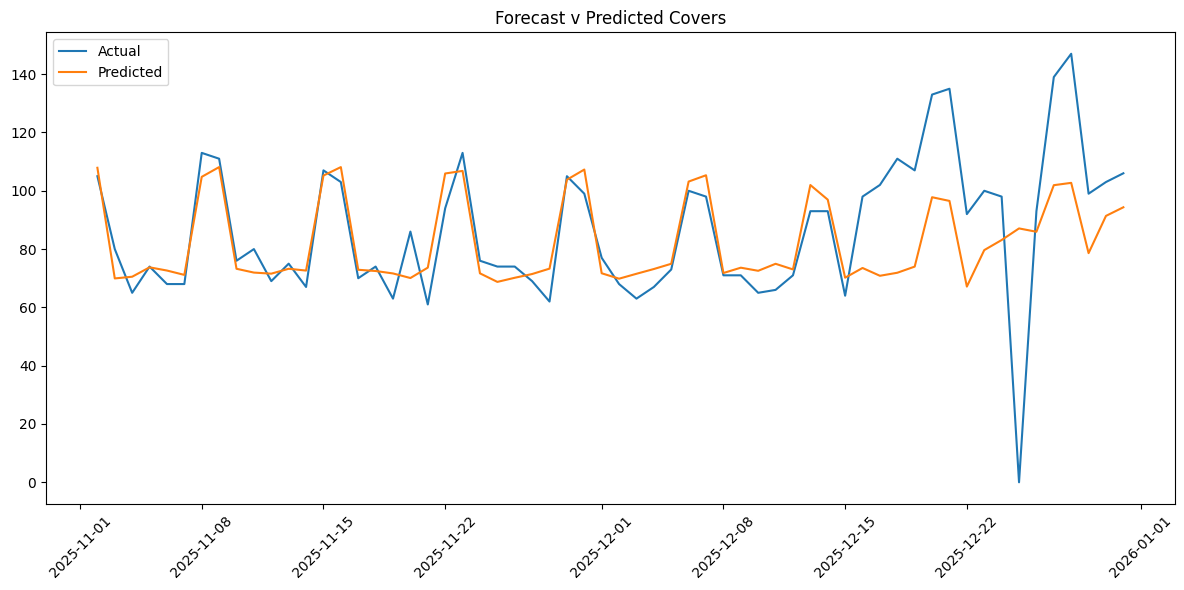

In [92]:
# --- Forecast v Actual Visualization ---
plt.figure(figsize=(12,6))

plt.plot(test['date'], y_test, label="Actual")
plt.plot(test['date'], preds, label="Predicted")

plt.legend()
plt.title("Forecast v Predicted Covers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

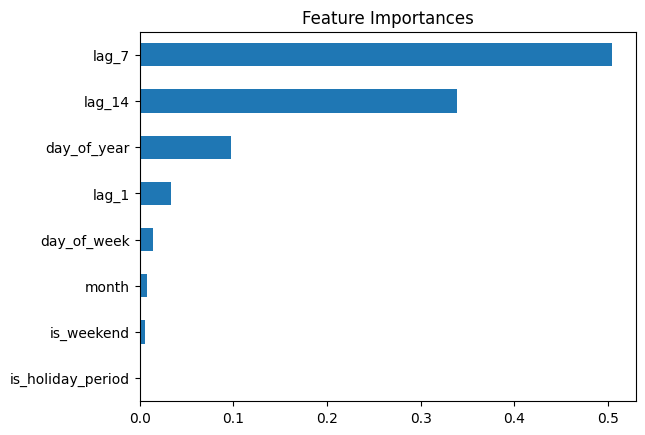

In [93]:
# --- Feature Importance ---

importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importances')
plt.show()

In [95]:
# --- Baseline model (Naive forecasting) ---

baseline_preds = test['lag_1']

baseline_mae = mean_absolute_error(y_test, baseline_preds)

print("Baseline MAE (Lag-1):", round(baseline_mae, 2))
print("Random Forest MAE:", round(mae, 2))



Baseline MAE (Lag-1): 17.6
Random Forest MAE: 11.96


In [99]:
# --- Linear Regression model  ---

from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_preds = lin_model.predict(X_test)

lin_mae = mean_absolute_error(y_test, lin_preds)

print("Linear Regression MAE:", round(lin_mae, 2))


Linear Regression MAE: 11.37


In [100]:
# --- Model comparison ---

print("\nModel Comparison:")
print("-------------------")
print("Baseline MAE:", round(baseline_mae, 2))
print("Linear Regression MAE:", round(lin_mae, 2))
print("Random Forest MAE:", round(mae, 2))


Model Comparison:
-------------------
Baseline MAE: 17.6
Linear Regression MAE: 11.37
Random Forest MAE: 11.96


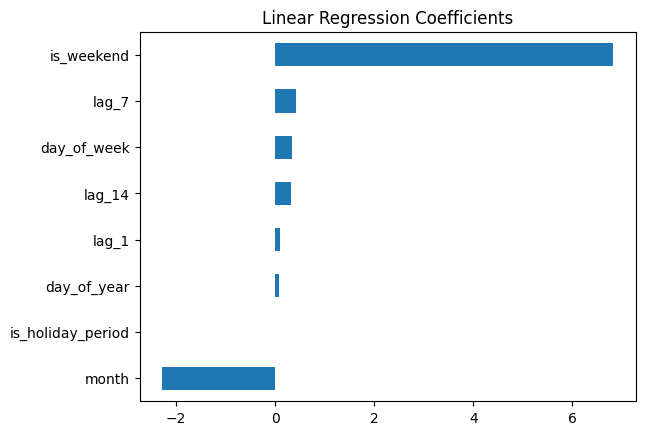

In [ ]:
# --- Linear Regession coefficients ---
coef_df = pd.Series(lin_model.coef_, index=features)
coef_df.sort_values().plot(kind='barh')
plt.title("Linear Regression Coefficients")
plt.show()


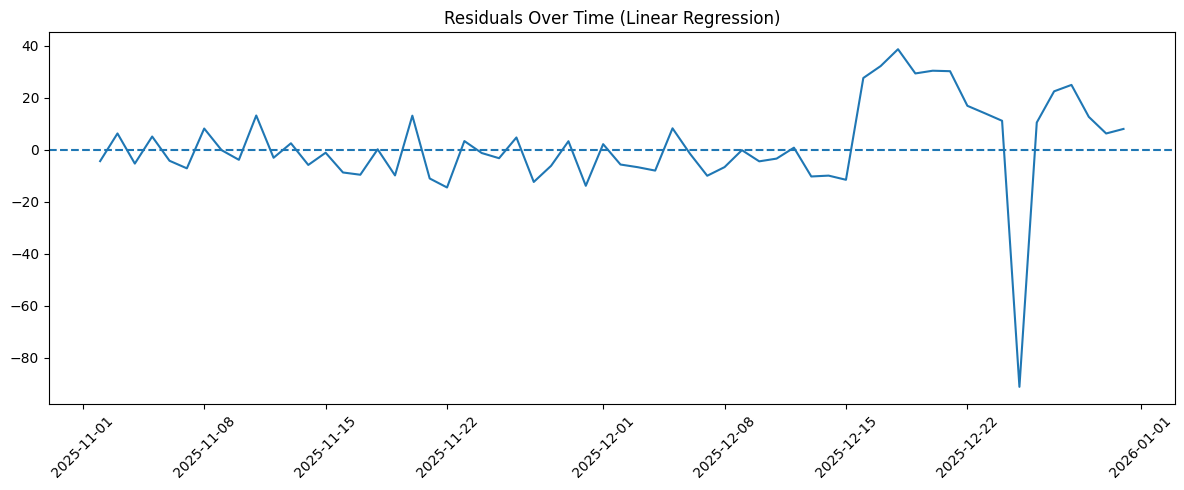

In [101]:
# --- Residual Analysis (Linear Regression) ---

lin_residuals = y_test - lin_preds

plt.figure(figsize=(12,5))
plt.plot(test['date'], lin_residuals)
plt.axhline(0, linestyle='--')
plt.title("Residuals Over Time (Linear Regression)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
"""
I've evaluated three forecasting approaches here:
    - Naive basline (lag-1)
    - Random Forest Regressor
    - Linear Regression

Linear Regression achieved the lowest MAE, showing
that the demand pattern in the dataset are largely
linear once lag and calendar features are taken into 
account.

Residual analysis shows forecasting errors increase 
during the busy Xmas period, due to limited historical
exposure.

From a business point of view, the model provides
stable and interpretable forecasts that are suitable
for short-term operational planning.
"""